In [1]:
library(dplyr)
library(Seurat)
library(patchwork)
library(ggplot2)
library(cowplot)
library(monocle)
library(reshape2)
library(stringr)
##library("phangorn",lib.loc = "/home/liqian7/tools/Anaconda3/envs/R4.3/lib/R/library/")
library(ggplot2)
library(scRNAtoolVis)
library(ggpubr)
library(ggVolcano)
library(latex2exp)
library(ggrepel)
options(warn=-1)####忽略警告


载入程辑包：‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


载入需要的程辑包：SeuratObject

载入需要的程辑包：sp


载入程辑包：‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



载入程辑包：‘cowplot’


The following object is masked from ‘package:patchwork’:

    align_plots


载入需要的程辑包：Matrix

载入需要的程辑包：Biobase

载入需要的程辑包：BiocGenerics


载入程辑包：‘BiocGenerics’


The following object is masked from ‘package:SeuratObject’:

    intersect


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, la

In [3]:
mer <- readRDS("./merge_allsample_stage_cellsubtype2.RDS")

In [4]:
sp1 <- subset(mer,subset = roi==1)
sp1@meta.data$type <- "100"
sp1@meta.data[which(sp1@meta.data$layer>50&sp1@meta.data$layer<=75),]$type <- "75"
sp1@meta.data[which(sp1@meta.data$layer>25&sp1@meta.data$layer<=50),]$type <- "50"
sp1@meta.data[which(sp1@meta.data$layer<=25),]$type <- "25"

In [5]:
table(sp1@meta.data$type)
sp2 <- subset(sp1,subset = type%in%c("25","100"))
sp2 <- subset(sp2,subset = sample=="save")


  100    25    50    75 
88035 71510 69553 70711 

In [6]:
unique(sp1@meta.data$week)
week <- c('W20_con','W0','W2','W6','W10','W20')

[1] "W10"   "W6"    "W2"    "W20"   "W20_N" "W0"

In [7]:
sp2@meta.data$type <- paste0(sp2@meta.data$first_type,"_",sp2@meta.data$type)

In [8]:
sp2@meta.data$type <- str_replace(sp2@meta.data$type,"Fibroblast","Fibro")
sp2@meta.data$type <- str_replace(sp2@meta.data$type,"Modulated_SMC","MSMC")

In [9]:
sp3 <- subset(sp2,subset = type%in%c("Fibro_25","MSMC_100"))
table(sp3@meta.data$type)


Fibro_25 MSMC_100 
   13674    17112 

In [10]:
table(sp3@meta.data$satge_p_all)


stage1 stage2 stage3 stage4 
  5844    974   1968  22000 

In [12]:
sp4 <- subset(sp3,subset = satge_p_all%in%c("stage3","stage4"))
table(sp4@meta.data$week)


  W10   W20    W6 
 5561 17432   975 

In [14]:
table(sp4@meta.data$type)


Fibro_25 MSMC_100 
    8561    15407 

In [19]:
saveRDS(sp4,"/DATA/User/liqian7/pienapple/07fn_add_coding/03figure3/3g.RDS")

In [15]:
sp4@meta.data$type <- factor(sp4@meta.data$type,levels = c("MSMC_100","Fibro_25"))
Idents(sp4) <- as.factor(sp4@meta.data$type)

In [16]:
deg = FindMarkers(sp4,ident.1 = 'MSMC_100',
            ident.2 = 'Fibro_25')
head(deg[order(deg$p_val),])

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Fn1,0,3.596174,0.662,0.110,0
Spp1,0,2.828896,0.727,0.214,0
Clu,0,2.463949,0.555,0.132,0
Lum,0,1.820410,0.641,0.231,0
Ctsd,0,1.309589,0.646,0.303,0
Ctsb,0,1.273896,0.674,0.337,0


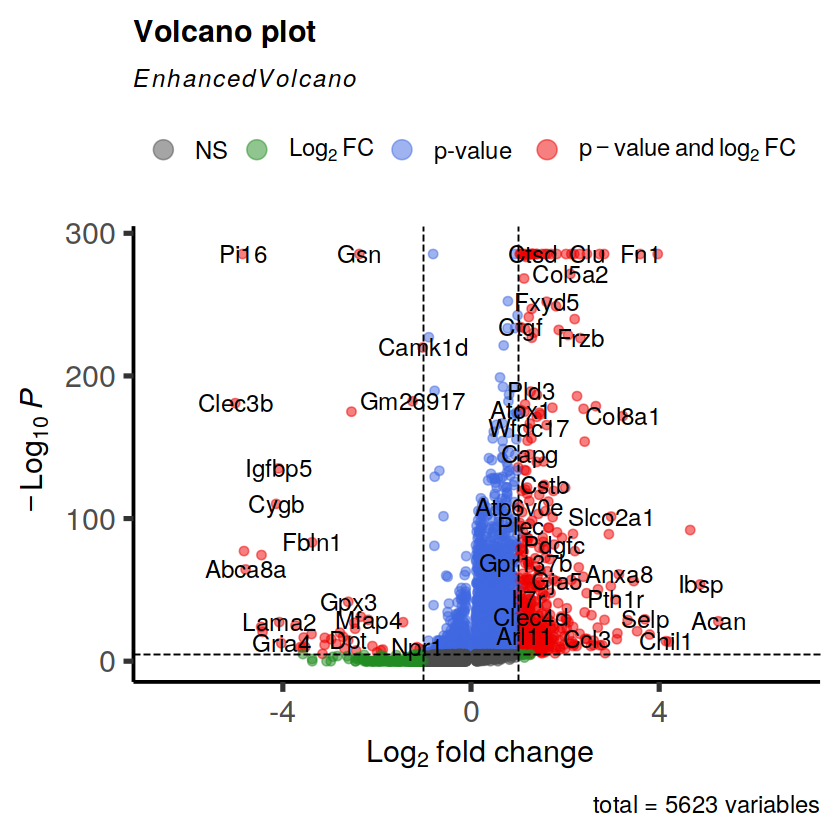

In [18]:
library(EnhancedVolcano) 
p1 <- EnhancedVolcano(deg,gridlines.major = FALSE,gridlines.minor = FALSE,
                lab = rownames(deg),
                x = 'avg_log2FC',
                y = 'p_val_adj')
p1